In [2]:
""" Carbon fluxes in Paul's observations """
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *
from scipy.stats import linregress, t
import itertools as it
from scipy.stats import gaussian_kde
import seaborn as sns
from matplotlib.cm import get_cmap


date = '20240407'
prefix = f'UQ_{date}_OAT'
N = 495
BLOCK = 99
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'NPP', 'HR', 'NEE'] # , 'TOTSOMC']
VAR_SUBSET = ['AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
              'BGNPP_TreeShrub', 'NPP', 'HR']
varid_subset = np.array([i for i in range(len(VAR_LIST)) if VAR_LIST[i] in VAR_SUBSET])

# The dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
collect = np.empty([N, len(VAR_LIST), 2, 4], float)
for b in range(0, N // BLOCK):
    collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(path_out, "extract", prefix, f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
# convert Inf's to NaN
collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
# revert the signs of NEE & HR to be compatible with Paul's data
# collect[:, -3:-1, :, :] = - collect[:, -3:-1, :, :]
# TEMPORARY
collect[:, -2:, :, :] = - collect[:, -2:, :, :]

In [3]:
# Get the sample values
samples = np.loadtxt(os.path.join('calibration_files', f'mcsamples_{date}_OAT.txt'))
names = pd.read_csv(os.path.join('calibration_files', f'parm_file_{date}_OAT'), sep = ' ', 
                    header=None, index_col = [0,1])

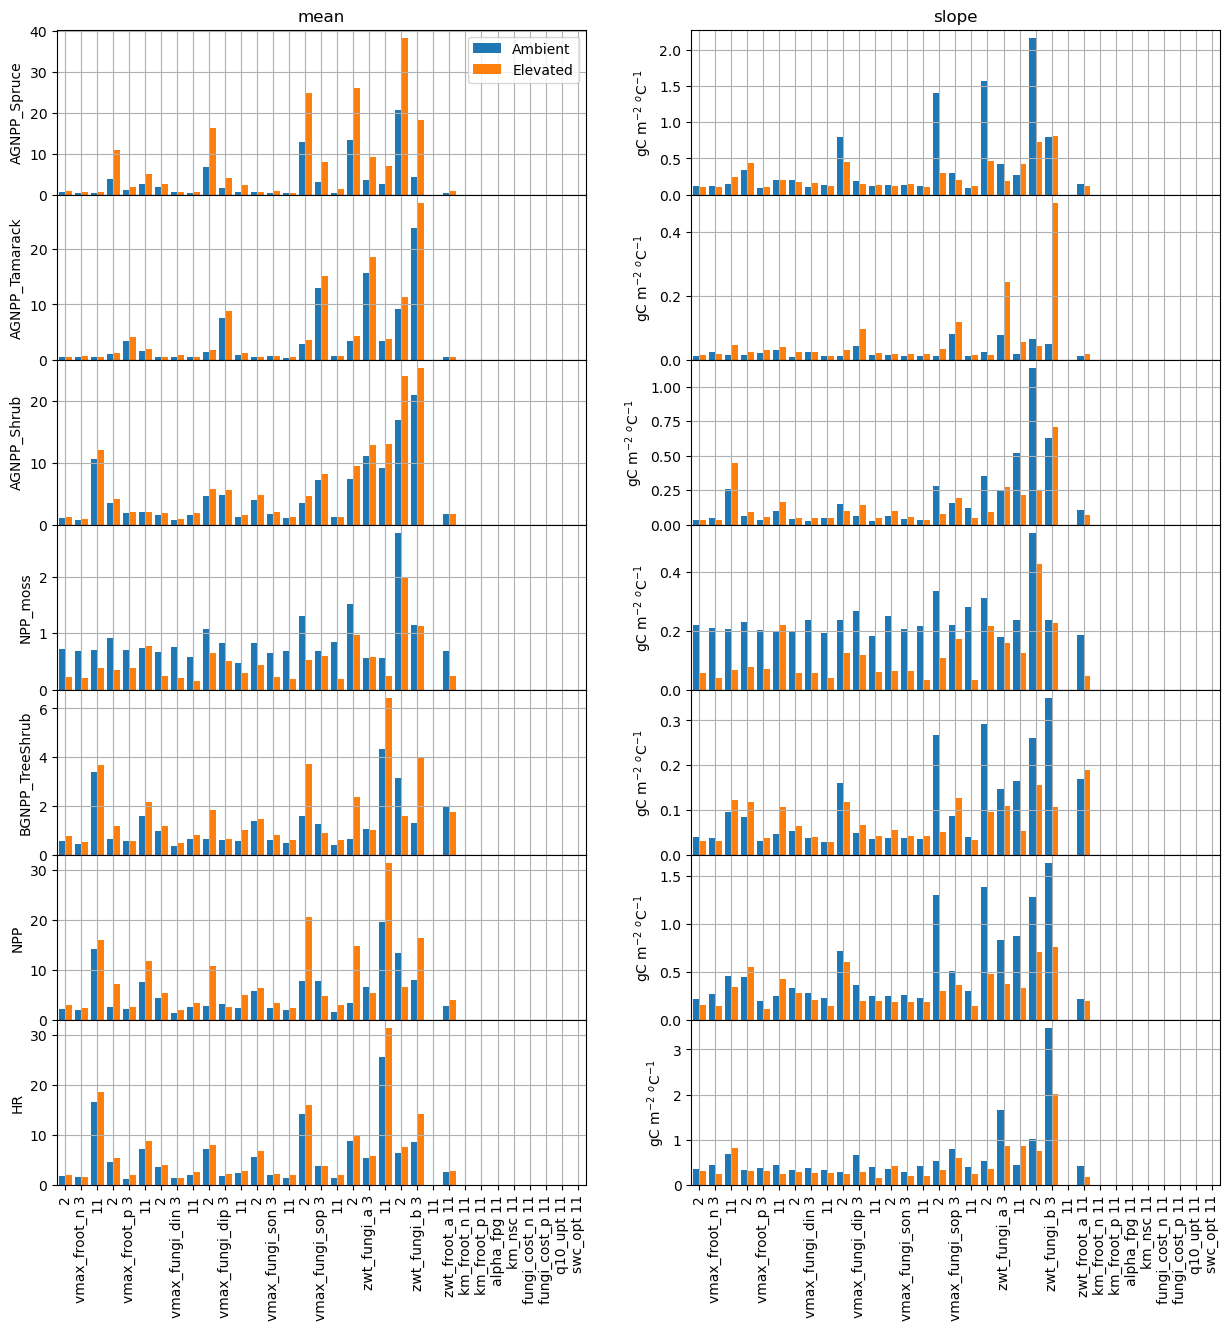

In [18]:
######################################################
# Plot the sensitivity of the individual parameters
# Also record the top 4 most sensitive parameters
######################################################

# aggregate the labels that have multiple pfts
parlist_labels = []
for i, (parname, pft) in enumerate(names.index):
    if (i < 24) and (pft != 3):
        parlist_labels.append(pft)
    else:
        parlist_labels.append(f'{parname} {pft}')

nsel = 5 # number of most sensitive parameters to check
selected_parameters = []

#
fig, axes = plt.subplots(7, 2, figsize = (15, 15), sharey = False, sharex = True)
fig.subplots_adjust(hspace = 0)
for v, varid in enumerate(varid_subset):

    result_mean_std = np.full([names.shape[0], 2], np.nan)
    result_slope_std = np.full([names.shape[0], 2], np.nan)

    for i, (parname, pft) in enumerate(names.index):
        # mean - 0, slope - 2
        result_mean = collect[(i*15):(i*15+15),varid,:,0]
        result_slope = collect[(i*15):(i*15+15),varid,:,2]
        # calculate the CV (%) resulting from parameter variation
        result_mean_std[i, :] = np.std(result_mean, axis = 0) #/ \
            #np.mean(np.abs(result_mean), axis = 0) * 100
        result_slope_std[i, :] = np.std(result_slope, axis = 0) #/ \
            #np.mean(np.abs(result_slope), axis = 0) * 100

    # the maximum sensitivity between ambient and elevated CO2
    # base on the result_mean because result_slope is similar
    ranked = np.argsort(np.max(result_mean_std, axis = 1))[::-1]
    selected_parameters.append(names.index[ranked[:nsel]])

    ax = axes[v, 0]
    for c, co2 in enumerate(['amb', 'elev']):
        ax.bar(height = result_mean_std[:, c], 
               x = np.arange(1, names.shape[0]+1) + 0.4 * c - 0.2, 
               width = 0.4)
    ax.set_xticks(np.arange(1, names.shape[0]+1))
    ax.set_xticklabels(parlist_labels, rotation = 90)
    #ax.set_ylim([0, 25])
    ax.set_xlim([0.5, names.shape[0] + 0.5])
    ax.grid(True)
    #ax.set_ylabel('CV (%)') 
    ax.set_ylabel('gC m$^{-2}$')
    if v == 0:
        ax.set_title('mean')
        ax.legend(['Ambient','Elevated'])
    ax.set_ylabel(VAR_LIST[varid])

    ax = axes[v, 1]
    for c, co2 in enumerate(['amb', 'elev']):
        ax.bar(height = result_slope_std[:, c], 
               x = np.arange(1, names.shape[0]+1) + 0.4 * c - 0.2, 
               width = 0.4)
    ax.set_xticks(np.arange(1, names.shape[0]+1))
    ax.set_xticklabels(parlist_labels, rotation = 90)
    #ax.set_ylim([0, 125])
    ax.set_xlim([0.5, names.shape[0] + 0.5])
    ax.grid(True)
    #ax.set_ylabel('CV (%)')
    ax.set_ylabel('gC m$^{-2}$ $^o$C$^{-1}$')
    if v == 0:
        ax.set_title('slope')

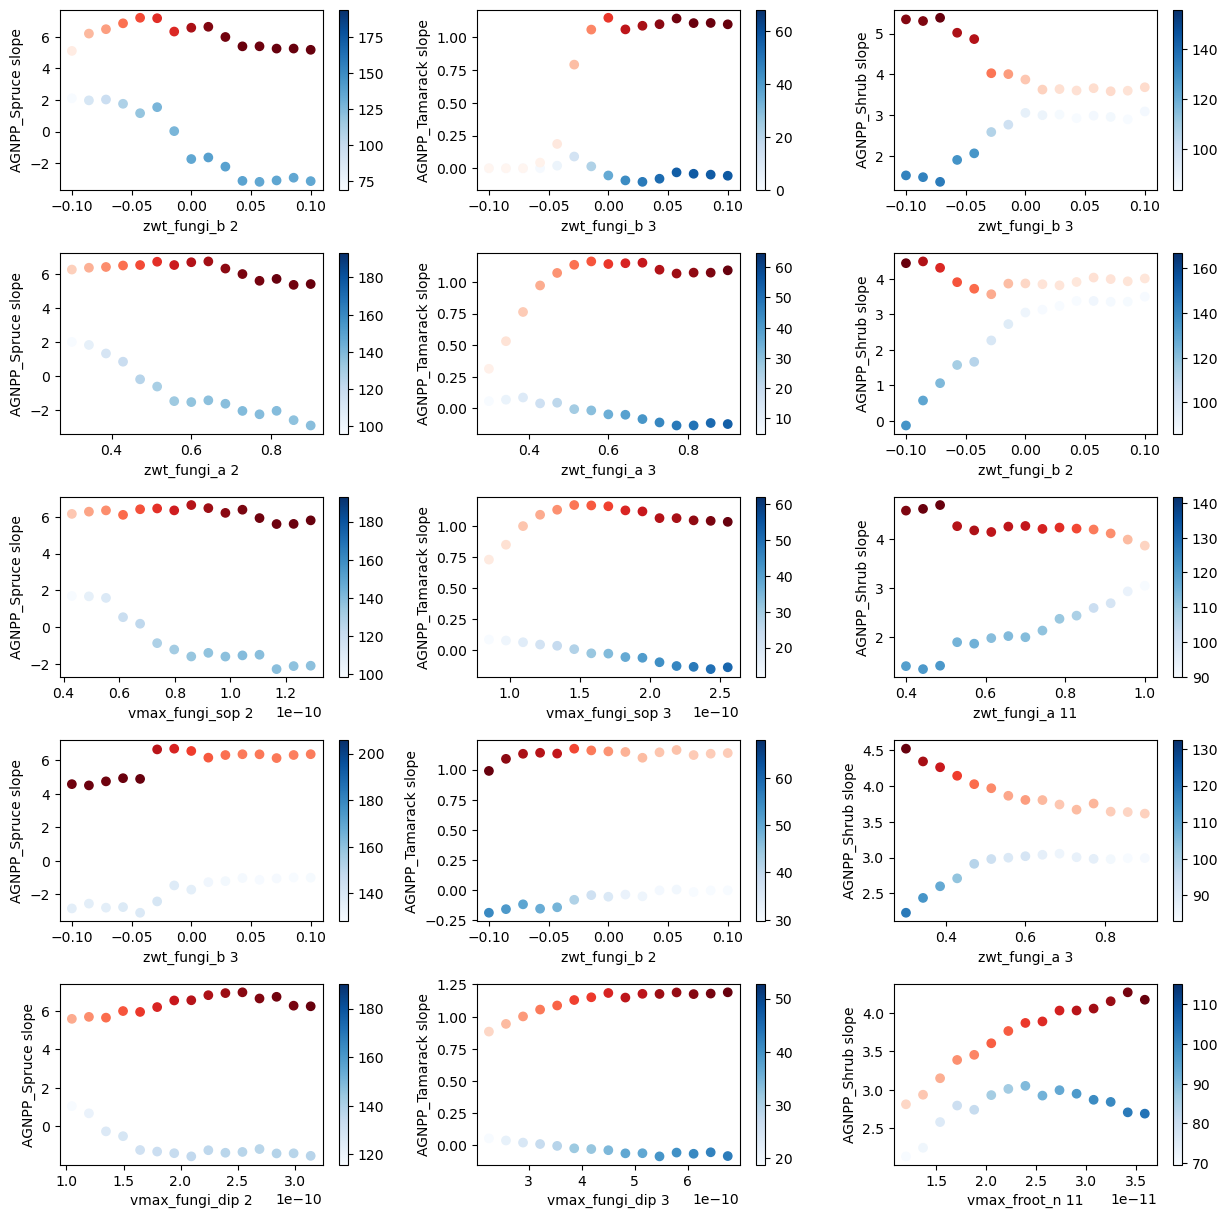

In [33]:
######################################################
# Plot the partial dependence plot for the most 
# sensitive parameters
######################################################
fig, axes = plt.subplots(nsel, 3, figsize = (15, 15), sharey = False, sharex = False)
fig.subplots_adjust(hspace = 0.35, wspace = 0.27)
for v in range(3):
    varid = varid_subset[v]
    params = selected_parameters[v]

    for p, (parname0, pft0) in enumerate(params):
        for i, (parname, pft) in enumerate(names.index):
            parfiles = samples[(i*15):(i*15+15), i]
            if (parname == parname0) & (pft == pft0):
                # mean - 0, slope - 2
                result_mean = collect[(i*15):(i*15+15),varid,:,0]
                result_slope = collect[(i*15):(i*15+15),varid,:,2]

                ax = axes[p, v]
                cf1 = ax.scatter(parfiles, result_slope[:, 0], c = result_mean[:, 0], 
                                 cmap = 'Blues', label = 'amb', vmin = result_mean.min(), 
                                 vmax = result_mean.max())
                cf2 = ax.scatter(parfiles, result_slope[:, 1], c = result_mean[:, 1], 
                                 cmap = 'Reds', label = 'elev', vmin = result_mean.min(), 
                                 vmax = result_mean.max())

                ax.set_xlabel(f'{parname} {pft}')
                #ax.set_xlabel(f'{VAR_LIST[varid]} mean')
                ax.set_ylabel(f'{VAR_LIST[varid]} slope')

                plt.colorbar(cf1, ax = ax)
                #plt.colorbar(cf2, ax = ax)